# ASCON-AEAD-128 Byte 00 Top-k Accuracy Test Notebook

This notebook is for a **small TEST_MODE dataset** collected from ASCON-AEAD-128 byte 00.

It checks:

- Metadata and trace consistency
- Single-trace Top-1, Top-2, Top-4, Top-8, Top-16, Top-32 accuracy
- Grouped multi-trace Top-k accuracy where enough repeated labels exist

Important: if the dataset only has around **100 traces**, this is only a **pipeline sanity test**, not a real accuracy result. For real 256-class key-byte learning, you need thousands of traces and ideally the full 30,000 traces per byte.

## 1. Imports and Environment Check

In [1]:
import sys
import os
import math
import random
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python executable: C:\Users\thetp\anaconda3\envs\acorn_train\python.exe
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3070


## 2. Configuration

In [2]:
# =========================
# Dataset path from your TEST_MODE collection
# =========================
DATASET_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623")
TARGET_BYTE = 0
BYTE_DIR = DATASET_ROOT / f"byte_{TARGET_BYTE:02d}"

# Output folder for this test notebook
RESULTS_DIR = DATASET_ROOT / "byte00_testmode_accuracy_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Top-k settings
TOPK_VALUES = (1, 2, 4, 8, 16, 32)
GROUP_SIZES = (1, 2, 4, 8, 12, 16)

# Training settings for small TEST_MODE data
SEED = 42
EPOCHS = 40
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Split mode:
#   "holdout" = train/val/test split. This is more honest, but very weak with only 100 traces.
#   "overfit_sanity" = train and evaluate on same traces. Use only to confirm the pipeline can run/memorize.
EVAL_MODE = "holdout"   # change to "overfit_sanity" only for pipeline sanity check

# For small data, keep trace model small.
TRACE_CROP_START = None   # e.g. 0
TRACE_CROP_END = None     # e.g. 2000

print("DATASET_ROOT:", DATASET_ROOT)
print("BYTE_DIR:", BYTE_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("EVAL_MODE:", EVAL_MODE)

DATASET_ROOT: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623
BYTE_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623\byte_00
RESULTS_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623\byte00_testmode_accuracy_results
EVAL_MODE: holdout


## 3. Load Metadata and Traces

In [3]:
trace_files = sorted(BYTE_DIR.glob(f"byte{TARGET_BYTE:02d}_chunk_*_traces.npz"))
meta_files = sorted(BYTE_DIR.glob(f"byte{TARGET_BYTE:02d}_chunk_*_metadata.csv"))

print("Trace files:", len(trace_files))
print("Metadata files:", len(meta_files))

if len(trace_files) == 0:
    raise FileNotFoundError(f"No trace files found in {BYTE_DIR}")
if len(trace_files) != len(meta_files):
    raise ValueError(f"Mismatch: {len(trace_files)} trace chunks vs {len(meta_files)} metadata chunks")

X_list = []
meta_list = []

for trace_path, meta_path in zip(trace_files, meta_files):
    with np.load(trace_path) as npz:
        if "traces" in npz.files:
            traces = npz["traces"]
        elif len(npz.files) == 1:
            traces = npz[npz.files[0]]
        else:
            raise KeyError(f"Cannot identify trace array in {trace_path}. Keys: {npz.files}")

    meta = pd.read_csv(meta_path)

    if len(traces) != len(meta):
        raise ValueError(f"Row mismatch: {trace_path.name} has {len(traces)} traces but {meta_path.name} has {len(meta)} rows")

    X_list.append(traces.astype(np.float32, copy=False))
    meta_list.append(meta)

X = np.vstack(X_list).astype(np.float32, copy=False)
meta = pd.concat(meta_list, ignore_index=True)

y = meta["key_byte_value"].astype(np.int64).values

if TRACE_CROP_START is not None or TRACE_CROP_END is not None:
    X = X[:, TRACE_CROP_START:TRACE_CROP_END]

print("X shape:", X.shape)
print("Metadata rows:", len(meta))
print("Class count:", len(np.unique(y)))
print("Min label:", y.min(), "Max label:", y.max())
print("Trace dtype:", X.dtype)

display(meta.head())

Trace files: 1
Metadata files: 1
X shape: (100, 2000)
Metadata rows: 100
Class count: 82
Min label: 0 Max label: 255
Trace dtype: float32


,algorithm,target_byte,trace_index,attempt_index,key_hex,nonce_hex,key_byte_value,key_byte_hex,key_byte_hw,output_hex,...,capture_ret,raw_text,bit0_lsb,bit1_lsb,bit2_lsb,bit3_lsb,bit4_lsb,bit5_lsb,bit6_lsb,bit7_lsb
0,ASCON-AEAD-128,0,0,1,28bf84d0d6a2a170eae1111ddce0b860,0,40,28,2,b7,...,False,rB7\nz00\n,0,0,0,1,0,1,0,0
1,ASCON-AEAD-128,0,1,2,3c15f2a7c6c35c9a60279dc1555079b9,0,60,3c,4,31,...,False,r31\nz00\n,0,0,1,1,1,1,0,0
2,ASCON-AEAD-128,0,2,3,6b44e9c452b4167ed936efde3d836d4e,0,107,6b,5,fb,...,False,rFB\nz00\n,1,1,0,1,0,1,1,0
3,ASCON-AEAD-128,0,3,4,6c0224ef1ece839a95e88348ab7443d2,0,108,6c,4,21,...,False,r21\nz00\n,0,0,1,1,0,1,1,0
4,ASCON-AEAD-128,0,4,5,da16a286d7f1f3c216c0c844aa9751d9,0,218,da,5,95,...,False,r95\nz00\n,0,1,0,1,1,0,1,1


## 4. Metadata Sanity Checks

In [4]:
checks = []

# Basic checks
checks.append({"check": "metadata_rows", "value": len(meta), "status": "OK" if len(meta) == len(X) else "FAIL"})
checks.append({"check": "target_byte_unique", "value": sorted(meta["target_byte"].unique().tolist()), "status": "OK" if set(meta["target_byte"].unique()) == {TARGET_BYTE} else "FAIL"})

# capture_ret: in ChipWhisperer, False usually means capture succeeded.
if "capture_ret" in meta.columns:
    capture_counts = meta["capture_ret"].astype(str).value_counts().to_dict()
    checks.append({"check": "capture_ret_counts", "value": capture_counts, "status": "OK"})

if "trigger_count" in meta.columns:
    trig = pd.to_numeric(meta["trigger_count"], errors="coerce")
    checks.append({"check": "trigger_count_min", "value": float(trig.min()), "status": "OK" if trig.min() > 0 else "FAIL"})
    checks.append({"check": "trigger_count_max", "value": float(trig.max()), "status": "OK"})
    checks.append({"check": "trigger_count_unique", "value": int(trig.nunique()), "status": "OK"})

# key_hex vs key_byte_value consistency
bad_key_rows = []
for i, row in meta.iterrows():
    key_hex = str(row["key_hex"])
    tb = int(row["target_byte"])
    expected = int(key_hex[tb*2:tb*2+2], 16)
    actual = int(row["key_byte_value"])
    if expected != actual:
        bad_key_rows.append(i)

checks.append({"check": "key_hex_matches_key_byte_value", "value": len(bad_key_rows), "status": "OK" if len(bad_key_rows) == 0 else "FAIL"})

# bit label consistency
bad_bit_rows = []
for i, row in meta.iterrows():
    val = int(row["key_byte_value"])
    for b in range(8):
        col = f"bit{b}_lsb"
        if col in meta.columns:
            if int(row[col]) != ((val >> b) & 1):
                bad_bit_rows.append(i)
                break

checks.append({"check": "bit_labels_match_key_byte_value", "value": len(bad_bit_rows), "status": "OK" if len(bad_bit_rows) == 0 else "FAIL"})

# Class distribution
class_counts = meta["key_byte_value"].value_counts().sort_index()
checks.append({"check": "unique_key_byte_classes", "value": int(class_counts.shape[0]), "status": "OK"})
checks.append({"check": "min_class_count", "value": int(class_counts.min()), "status": "WARN" if class_counts.min() < 2 else "OK"})
checks.append({"check": "max_class_count", "value": int(class_counts.max()), "status": "OK"})

check_df = pd.DataFrame(checks)
display(check_df)

check_path = RESULTS_DIR / "byte00_testmode_metadata_checks.csv"
check_df.to_csv(check_path, index=False)
print("Saved metadata checks to:", check_path)

print("\nClass count summary:")
display(class_counts.describe())

if len(meta) < 1000:
    print("\nWARNING: This is a very small TEST_MODE dataset. Accuracy values are only for pipeline testing, not final reporting.")
if class_counts.min() < 2:
    print("WARNING: Some key-byte classes appear only once. Stratified train/test split is not reliable.")
if class_counts.shape[0] < 256:
    print("WARNING: Not all 256 key-byte classes are present. A 256-class classifier cannot be fairly evaluated yet.")

,check,value,status
0,metadata_rows,100,OK
1,target_byte_unique,[0],OK
2,capture_ret_counts,{'False': 100},OK
3,trigger_count_min,332.0,OK
4,trigger_count_max,332.0,OK
5,trigger_count_unique,1,OK
6,key_hex_matches_key_byte_value,0,OK
7,bit_labels_match_key_byte_value,0,OK
8,unique_key_byte_classes,82,OK
9,min_class_count,1,WARN


Saved metadata checks to: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623\byte00_testmode_accuracy_results\byte00_testmode_metadata_checks.csv

Class count summary:


count    82.000000
mean      1.219512
std       0.497510
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: count, dtype: float64

## 5. Preprocess and Split Data

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = device == "cuda"
print("Device:", device)

# Replace NaN/Inf and remove DC offset per trace.
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
X = X - X.mean(axis=1, keepdims=True)

indices = np.arange(len(y))

if EVAL_MODE == "overfit_sanity":
    # Use same data for train/val/test only to confirm pipeline runs.
    X_train, y_train, idx_train = X, y, indices
    X_val, y_val, idx_val = X, y, indices
    X_test, y_test, idx_test = X, y, indices
else:
    # With TEST_MODE=100 traces, stratification is usually impossible.
    # Use random split and clearly mark the result as preliminary.
    X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
        X, y, indices,
        test_size=0.30,
        random_state=SEED,
        shuffle=True,
        stratify=None,
    )
    X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
        X_temp, y_temp, idx_temp,
        test_size=0.50,
        random_state=SEED,
        shuffle=True,
        stratify=None,
    )

# Standardize using training statistics only.
mean = X_train.mean(axis=0, keepdims=True).astype(np.float32)
std = (X_train.std(axis=0, keepdims=True) + 1e-6).astype(np.float32)

X_train = ((X_train - mean) / std).astype(np.float32, copy=False)
X_val = ((X_val - mean) / std).astype(np.float32, copy=False)
X_test = ((X_test - mean) / std).astype(np.float32, copy=False)

print("Train:", X_train.shape, y_train.shape, "unique labels:", len(np.unique(y_train)))
print("Val:  ", X_val.shape, y_val.shape, "unique labels:", len(np.unique(y_val)))
print("Test: ", X_test.shape, y_test.shape, "unique labels:", len(np.unique(y_test)))

# Save split mapping.
split_map = meta.copy()
split_map["original_loaded_index"] = np.arange(len(split_map))
split_map["split"] = "unused"
split_map.loc[idx_train, "split"] = "train"
split_map.loc[idx_val, "split"] = "validation"
split_map.loc[idx_test, "split"] = "test"
split_path = RESULTS_DIR / f"byte{TARGET_BYTE:02d}_testmode_split_mapping.csv"
split_map.to_csv(split_path, index=False)
print("Saved split mapping to:", split_path)

Device: cuda
Train: (70, 2000) (70,) unique labels: 61
Val:   (15, 2000) (15,) unique labels: 14
Test:  (15, 2000) (15,) unique labels: 15
Saved split mapping to: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623\byte00_testmode_accuracy_results\byte00_testmode_split_mapping.csv


## 6. Small 1D CNN Model

In [6]:
class TraceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class SmallCNN256(nn.Module):
    def __init__(self, num_classes=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

train_loader = DataLoader(TraceDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=PIN_MEMORY)
val_loader = DataLoader(TraceDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)
test_loader = DataLoader(TraceDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)

model = SmallCNN256(num_classes=256).to(device)
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

SmallCNN256(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(11,), stride=(1,), padding=(5,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=64, out_features=256, bias=True)
  )
)
Parameters: 30976


## 7. Top-k and Grouped Evaluation Functions

In [7]:
def topk_accuracy_from_logits(logits, y_true, ks=TOPK_VALUES):
    results = {}
    max_k = max(ks)
    top_idx = logits.topk(max_k, dim=1).indices
    for k in ks:
        results[f"top{k}"] = top_idx[:, :k].eq(y_true.view(-1, 1)).any(dim=1).float().mean().item()
    return results


def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    logits_list = []
    y_list = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            total_samples += len(yb)
            logits_list.append(logits.cpu())
            y_list.append(yb.cpu())
    logits_all = torch.cat(logits_list, dim=0)
    y_all = torch.cat(y_list, dim=0)
    avg_loss = total_loss / max(total_samples, 1)
    topk = topk_accuracy_from_logits(logits_all, y_all, ks=TOPK_VALUES)
    return avg_loss, topk, logits_all, y_all


def grouped_topk(logits, y_true, group_sizes=GROUP_SIZES, ks=TOPK_VALUES, seed=42):
    """Combine predictions from traces with the same true byte value.

    With TEST_MODE=100 traces, many group sizes may be impossible because most classes
    appear only once. Those results will return NaN and num_groups=0.
    """
    rng = np.random.default_rng(seed)
    log_probs = F.log_softmax(logits, dim=1).numpy()
    y_np = y_true.numpy()

    rows = []
    for n in group_sizes:
        correct = {f"top{k}": 0 for k in ks}
        total_groups = 0

        for cls in np.unique(y_np):
            idx = np.where(y_np == cls)[0]
            if len(idx) < n:
                continue
            rng.shuffle(idx)
            n_groups = len(idx) // n
            idx = idx[:n_groups*n].reshape(n_groups, n)
            for group_idx in idx:
                scores = log_probs[group_idx].sum(axis=0)
                ranked = np.argsort(-scores)
                for k in ks:
                    if cls in ranked[:k]:
                        correct[f"top{k}"] += 1
                total_groups += 1

        row = {"group_size_n": n, "num_groups": total_groups}
        for k in ks:
            row[f"grouped_n{n}_top{k}"] = np.nan if total_groups == 0 else correct[f"top{k}"] / total_groups
        rows.append(row)

    return pd.DataFrame(rows)

## 8. Train Model

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = []
best_val_top4 = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_samples = 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(yb)
        train_samples += len(yb)

    train_loss = train_loss_sum / max(train_samples, 1)
    val_loss, val_topk, _, _ = evaluate_model(model, val_loader, criterion)

    row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss}
    row.update({f"val_{k}": v for k, v in val_topk.items()})
    history.append(row)

    if val_topk["top4"] > best_val_top4:
        best_val_top4 = val_topk["top4"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"Top1={val_topk['top1']:.4f} | Top2={val_topk['top2']:.4f} | "
        f"Top4={val_topk['top4']:.4f} | Top8={val_topk['top8']:.4f} | "
        f"Top16={val_topk['top16']:.4f} | Top32={val_topk['top32']:.4f}"
    )

history_df = pd.DataFrame(history)
history_path = RESULTS_DIR / f"byte{TARGET_BYTE:02d}_testmode_training_history_{EVAL_MODE}.csv"
history_df.to_csv(history_path, index=False)
print("Saved history to:", history_path)

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01/40 | train_loss=5.5753 | val_loss=5.5788 | Top1=0.0000 | Top2=0.0000 | Top4=0.0000 | Top8=0.0000 | Top16=0.0000 | Top32=0.0000
Epoch 02/40 | train_loss=5.4554 | val_loss=5.5811 | Top1=0.0000 | Top2=0.0000 | Top4=0.0000 | Top8=0.0667 | Top16=0.0667 | Top32=0.0667
Epoch 03/40 | train_loss=5.2857 | val_loss=5.5746 | Top1=0.0000 | Top2=0.0000 | Top4=0.0667 | Top8=0.0667 | Top16=0.0667 | Top32=0.0667
Epoch 04/40 | train_loss=5.1755 | val_loss=5.5652 | Top1=0.0000 | Top2=0.0667 | Top4=0.0667 | Top8=0.0667 | Top16=0.0667 | Top32=0.0667
Epoch 05/40 | train_loss=5.0672 | val_loss=5.5541 | Top1=0.0000 | Top2=0.0667 | Top4=0.0667 | Top8=0.0667 | Top16=0.0667 | Top32=0.1333
Epoch 06/40 | train_loss=4.9641 | val_loss=5.5444 | Top1=0.0000 | Top2=0.0667 | Top4=0.0667 | Top8=0.0667 | Top16=0.0667 | Top32=0.1333
Epoch 07/40 | train_loss=4.8274 | val_loss=5.5411 | Top1=0.0000 | Top2=0.0667 | Top4=0.0667 | Top8=0.0667 | Top16=0.0667 | Top32=0.2000
Epoch 08/40 | train_loss=4.7368 | val_loss=5.545

## 9. Final Single-Trace and Grouped Top-k Accuracy

In [9]:
test_loss, test_topk, test_logits, test_y = evaluate_model(model, test_loader, criterion)

grouped_df = grouped_topk(test_logits, test_y, group_sizes=GROUP_SIZES, ks=TOPK_VALUES, seed=SEED)

single_df = pd.DataFrame([{
    "eval_mode": EVAL_MODE,
    "target_byte": TARGET_BYTE,
    "num_total_traces": len(meta),
    "train_size": len(y_train),
    "val_size": len(y_val),
    "test_size": len(y_test),
    "unique_classes_total": len(np.unique(y)),
    "unique_classes_train": len(np.unique(y_train)),
    "unique_classes_test": len(np.unique(y_test)),
    "test_loss": test_loss,
    **test_topk,
}])

single_path = RESULTS_DIR / f"byte{TARGET_BYTE:02d}_single_trace_topk_{EVAL_MODE}.csv"
grouped_path = RESULTS_DIR / f"byte{TARGET_BYTE:02d}_grouped_topk_{EVAL_MODE}.csv"

single_df.to_csv(single_path, index=False)
grouped_df.to_csv(grouped_path, index=False)

print("Saved single-trace result to:", single_path)
print("Saved grouped result to:", grouped_path)

print("\nSingle-trace Top-k result:")
display(single_df)

print("\nGrouped Top-k result:")
display(grouped_df)

print("\nInterpretation warning:")
if len(meta) < 1000:
    print("This TEST_MODE dataset is too small for meaningful 256-class accuracy. Use this only to confirm the pipeline works.")
if grouped_df["num_groups"].max() == 0:
    print("Grouped evaluation could not be computed because there are not enough repeated labels per class in the test set.")
else:
    print("Grouped rows with num_groups > 0 are the only meaningful grouped rows.")

Saved single-trace result to: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623\byte00_testmode_accuracy_results\byte00_single_trace_topk_holdout.csv
Saved grouped result to: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_011623\byte00_testmode_accuracy_results\byte00_grouped_topk_holdout.csv

Single-trace Top-k result:


,eval_mode,target_byte,num_total_traces,train_size,val_size,test_size,unique_classes_total,unique_classes_train,unique_classes_test,test_loss,top1,top2,top4,top8,top16,top32
0,holdout,0,100,70,15,15,82,61,15,6.36941,0.0,0.0,0.0,0.0,0.0,0.0



Grouped Top-k result:


,group_size_n,num_groups,grouped_n1_top1,grouped_n1_top2,grouped_n1_top4,grouped_n1_top8,grouped_n1_top16,grouped_n1_top32,grouped_n2_top1,grouped_n2_top2,...,grouped_n12_top4,grouped_n12_top8,grouped_n12_top16,grouped_n12_top32,grouped_n16_top1,grouped_n16_top2,grouped_n16_top4,grouped_n16_top8,grouped_n16_top16,grouped_n16_top32
0,1,15,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Interpretation warning:
This TEST_MODE dataset is too small for meaningful 256-class accuracy. Use this only to confirm the pipeline works.
Grouped rows with num_groups > 0 are the only meaningful grouped rows.


## 10. Optional: Plot Training History

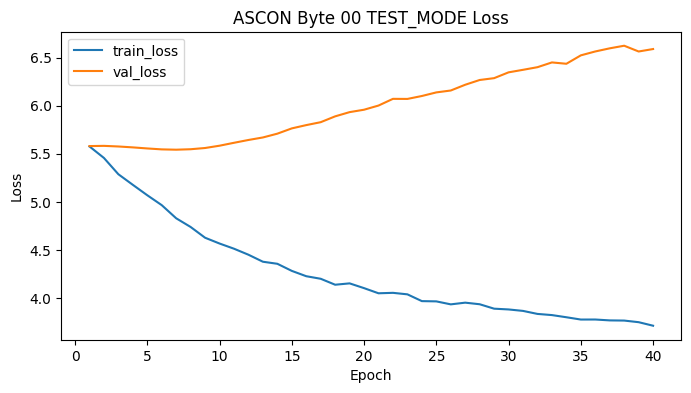

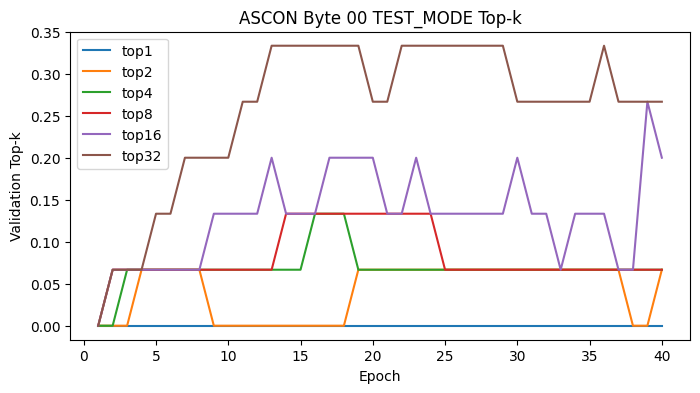

In [10]:
import matplotlib.pyplot as plt

if len(history_df) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"ASCON Byte {TARGET_BYTE:02d} TEST_MODE Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    for col in ["val_top1", "val_top2", "val_top4", "val_top8", "val_top16", "val_top32"]:
        if col in history_df.columns:
            plt.plot(history_df["epoch"], history_df[col], label=col.replace("val_", ""))
    plt.xlabel("Epoch")
    plt.ylabel("Validation Top-k")
    plt.title(f"ASCON Byte {TARGET_BYTE:02d} TEST_MODE Top-k")
    plt.legend()
    plt.show()

## 11. What Result Should You Expect?

For only 100 TEST_MODE traces, the result may be low or unstable. That does **not** mean ASCON leakage failed.

A proper test should use at least:

```text
1,000 traces for byte 00 as a quick learning test
5,000 traces for byte 00 as a better learning test
30,000 traces per byte for final model training
```

Random chance for 256-class Top-k is:

```text
Top1  = 1/256  = 0.0039
Top2  = 2/256  = 0.0078
Top4  = 4/256  = 0.0156
Top8  = 8/256  = 0.0313
Top16 = 16/256 = 0.0625
Top32 = 32/256 = 0.1250
```